<a href="https://colab.research.google.com/github/Prince6306238634/FP/blob/master/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Implementation of ANN and plot the results**

In [1]:
#importing files and packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.layers import Dense, Activation
from keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
#mounting to drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Dataset import
data = pd.read_csv("/content/drive/MyDrive/DA lab/titanic.csv")
data.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


Preprocessing of Data

In [4]:
data.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
data.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [5]:
target=data.Survived
inputs=data.drop('Survived',axis='columns')
inputs.columns[inputs.isna().any()]

Index(['Age'], dtype='object')

In [6]:
dummies=pd.get_dummies(inputs.Sex)
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [7]:
inputs=pd.concat([inputs,dummies],axis='columns')
inputs.head()

,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,False,True
1,1,female,38.0,71.2833,True,False
2,3,female,26.0,7.9250,True,False
3,1,female,35.0,53.1000,True,False
4,3,male,35.0,8.0500,False,True


In [ ]:
inputs.drop(['Sex','male'],axis='columns',inplace=True)
inputs.head(3)

,Pclass,Age,Fare,female
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1


In [ ]:
inputs.Age=inputs.Age.fillna(inputs.Age.mean())
inputs.head()

,Pclass,Age,Fare,female
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1
3,1,35.0,53.1000,1
4,3,35.0,8.0500,0


Data Training

In [ ]:
X = inputs.iloc[:,0:4].values.astype(float)
y = target.values.astype(float)

In [ ]:
# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .40,random_state=1)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# Initialising the ANN
model = Sequential()

In [ ]:
# Adding the input layer and the first hidden layer
model.add(Dense(4,input_dim=4, activation = 'relu'))
# Adding the second hidden layer
model.add(Dense(units = 4, activation = 'relu'))

# Adding the third hidden layer
#model.add(Dense(units = 15, activation = 'relu'))

# Adding the output layer

model.add(Dense(units = 2, activation='linear'))

In [ ]:
#model.add(Dense(1))
# Compiling the ANN
#model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
#ann_viz(model, view=True, title="test", filename="visualized")
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=['mae'])

In [ ]:
# Fitting the ANN to the Training set
model.fit(X_train, y_train, batch_size = 200, validation_split=0.40,epochs = 1000,  verbose=1)

Epoch 1/1000
2/2 [==============================] - 13s 430ms/step - loss: 0.2565 - mae: 0.3700 - val_loss: 0.2169 - val_mae: 0.3169
Epoch 2/1000
2/2 [==============================] - 0s 18ms/step - loss: 0.2523 - mae: 0.3696 - val_loss: 0.2140 - val_mae: 0.3183
Epoch 3/1000
2/2 [==============================] - 0s 18ms/step - loss: 0.2422 - mae: 0.3622 - val_loss: 0.2112 - val_mae: 0.3196
Epoch 4/1000
2/2 [==============================] - 0s 20ms/step - loss: 0.2338 - mae: 0.3603 - val_loss: 0.2086 - val_mae: 0.3209
Epoch 5/1000
2/2 [==============================] - 0s 23ms/step - loss: 0.2336 - mae: 0.3617 - val_loss: 0.2061 - val_mae: 0.3222
Epoch 6/1000
2/2 [==============================] - 0s 20ms/step - loss: 0.2380 - mae: 0.3716 - val_loss: 0.2037 - val_mae: 0.3233
Epoch 7/1000
2/2 [==============================] - 0s 20ms/step - loss: 0.2301 - mae: 0.3644 - val_loss: 0.2014 - val_mae: 0.3243
Epoch 8/1000
2/2 [==============================] - 0s 24ms/step - loss: 0.2319 -

Evaluating the result

In [ ]:
#acc_train = history.history['mae']
#acc_val = history.history['val_mae']
score=model.evaluate(X_test,y_test,verbose=1)
print(score)
y_pred = model.predict(X_test)

12/12 [==============================] - 0s 1ms/step - loss: 0.1547 - mae: 0.2981
[0.15472514927387238, 0.298120379447937]


Plotting the Result

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: MatplotlibDeprecationWarning: cycling among columns of inputs with non-matching shapes is deprecated.
  


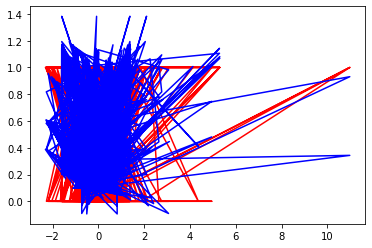

In [ ]:
plt.plot(X_test, y_test, color = 'red', label = 'Real dataTest')
plt.plot(X_test, y_pred, color = 'blue', label = 'Predicted datatest')